In [1]:
import tensorflow as tf
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random



from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

2026-03-14 17:11:40.168700: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773508300.577244      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773508300.683973      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773508301.647266      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773508301.647315      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773508301.647318      55 computation_placer.cc:177] computation placer alr

In [2]:
!nvidia-smi

Sat Mar 14 17:12:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
image_dir = "/kaggle/input/datasets/sakshaymahna/kittiroadsegmentation/training/image_2"
mask_dir  = "/kaggle/input/datasets/sakshaymahna/kittiroadsegmentation/training/gt_image_2"

images = os.listdir(image_dir)

print("Total images:", len(images))

Total images: 289


Image shape: (375, 1242, 3)


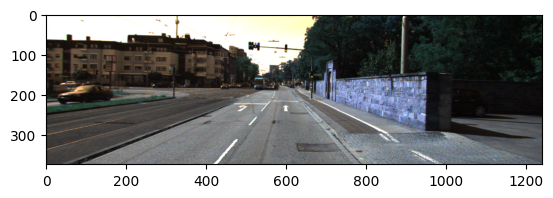

In [4]:
sample = images[10]

img = cv2.imread(os.path.join(image_dir, sample))
print("Image shape:", img.shape)

plt.imshow(img)

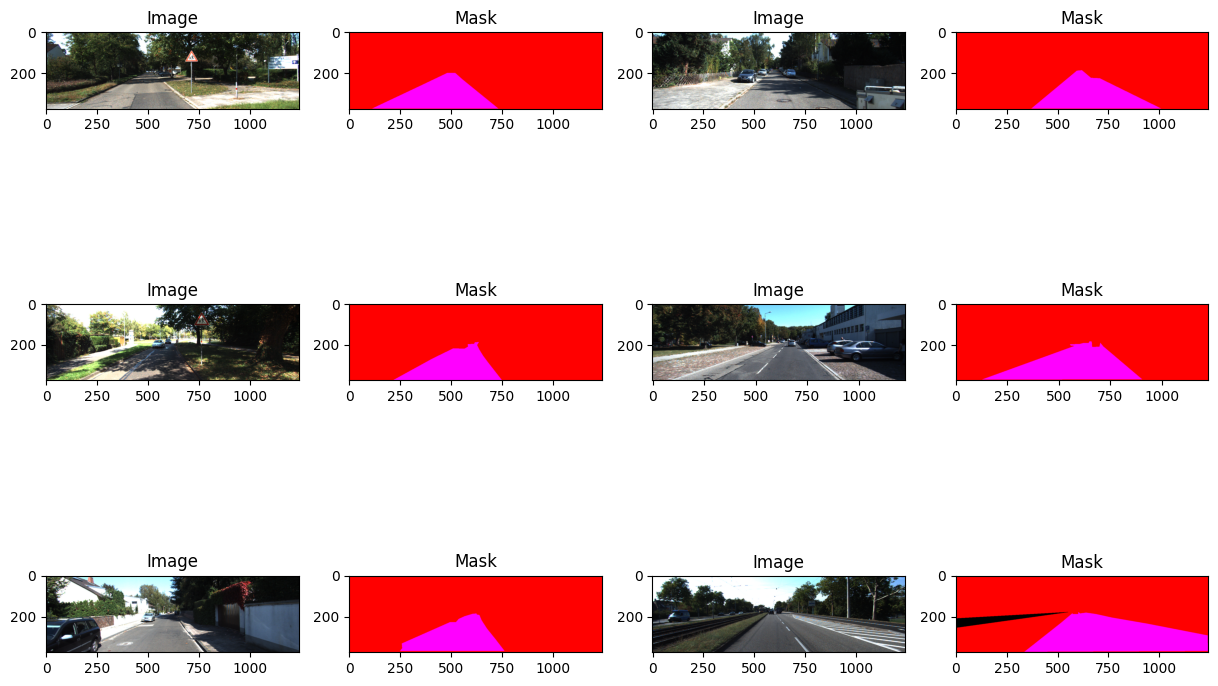

In [5]:
plt.figure(figsize=(15,10))

for i in range(6):

    sample = random.choice(images)

    prefix, rest = sample.split("_",1)
    mask_name = f"{prefix}_road_{rest}"

    img = cv2.imread(os.path.join(image_dir, sample))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(os.path.join(mask_dir, mask_name))
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    plt.subplot(3,4,i*2+1)
    plt.imshow(img)
    plt.title("Image")

    plt.subplot(3,4,i*2+2)
    plt.imshow(mask)
    plt.title("Mask")

plt.show()

In [6]:
pixels = []

for img_name in images[:50]:
    img = cv2.imread(os.path.join(image_dir, img_name))
    pixels.append(img.mean())

print("Mean pixel intensity:", np.mean(pixels))

Mean pixel intensity: 92.00490819996507


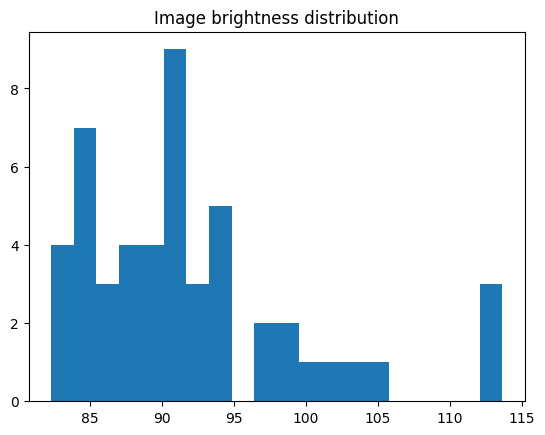

In [7]:
plt.hist(pixels, bins=20)
plt.title("Image brightness distribution")
plt.show()

In [8]:
for img_name in images[:5]:

    prefix, rest = img_name.split("_",1)
    mask_name = f"{prefix}_road_{rest}"

    print(img_name, "->", mask_name)

umm_000040.png -> umm_road_000040.png
uu_000047.png -> uu_road_000047.png
umm_000034.png -> umm_road_000034.png
umm_000006.png -> umm_road_000006.png
uu_000001.png -> uu_road_000001.png


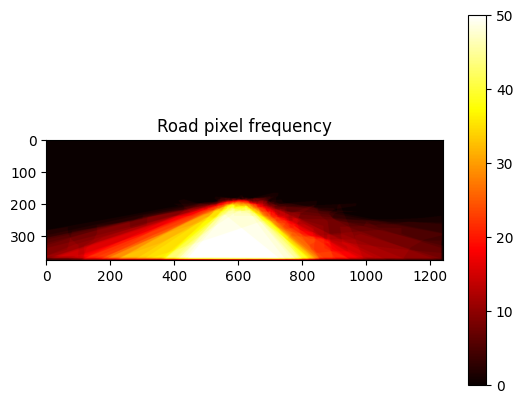

In [9]:
heatmap = np.zeros((375,1242))

for img_name in images[:50]:

    prefix, rest = img_name.split("_",1)
    mask_name = f"{prefix}_road_{rest}"

    mask = cv2.imread(os.path.join(mask_dir, mask_name))

    road = mask[:,:,0] == 255

    road = cv2.resize(road.astype(np.uint8), (1242,375))

    heatmap += road

plt.imshow(heatmap, cmap="hot")
plt.title("Road pixel frequency")
plt.colorbar()
plt.show()

In [10]:
def get_mask_name(img_name):
    prefix, rest = img_name.split("_",1)
    return f"{prefix}_road_{rest}"

In [11]:
IMG_SIZE = 256

def load_sample(img_name):

    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(mask_dir, get_mask_name(img_name))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path)

    # road pixels
    road = mask[:,:,0] == 255
    mask = road.astype(np.float32)

    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    mask = cv2.resize(mask,(IMG_SIZE,IMG_SIZE))

    mask = np.expand_dims(mask,axis=-1)

    return img, mask

In [12]:
X=[]
Y=[]

for img_name in images:
    
    img,mask = load_sample(img_name)

    X.append(img)
    Y.append(mask)

X = np.array(X)/255.0
Y = np.array(Y)

print(X.shape,Y.shape)

(289, 256, 256, 3) (289, 256, 256, 1)


In [14]:
from sklearn.model_selection import train_test_split

X_train,X_val,Y_train,Y_val = train_test_split(
    X,Y,test_size=0.2,random_state=42
)

In [15]:
def build_resnet_unet():

    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Encoder layers (skip connections)
    s1 = base.get_layer("conv1_relu").output
    s2 = base.get_layer("conv2_block3_out").output
    s3 = base.get_layer("conv3_block4_out").output
    s4 = base.get_layer("conv4_block6_out").output

    b1 = base.get_layer("conv5_block3_out").output

    # Decoder
    d1 = UpSampling2D((2,2))(b1)
    d1 = Concatenate()([d1,s4])
    d1 = Conv2D(512,3,padding="same",activation="relu")(d1)

    d2 = UpSampling2D((2,2))(d1)
    d2 = Concatenate()([d2,s3])
    d2 = Conv2D(256,3,padding="same",activation="relu")(d2)

    d3 = UpSampling2D((2,2))(d2)
    d3 = Concatenate()([d3,s2])
    d3 = Conv2D(128,3,padding="same",activation="relu")(d3)

    d4 = UpSampling2D((2,2))(d3)
    d4 = Concatenate()([d4,s1])
    d4 = Conv2D(64,3,padding="same",activation="relu")(d4)

    d5 = UpSampling2D((2,2))(d4)
    outputs = Conv2D(1,1,activation="sigmoid")(d5)

    model = Model(base.input,outputs)

    return model

In [16]:
model = build_resnet_unet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1773508389.126922      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773508389.132688      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 40,804,225 (155.66 MB)

 Trainable params: 40,751,105 (155.45 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [17]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val,Y_val),
    epochs=40,
    batch_size=8
)

Epoch 1/40


I0000 00:00:1773508426.672903     180 service.cc:152] XLA service 0x79b7bc0071b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773508426.672945     180 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773508426.672949     180 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773508432.567507     180 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-14 17:13:59.410041: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv %cudnn-conv-bias-activation.267 = (f32[8,256,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,1024,32,32]{3,2,1,0} %bitcast.71972, f32[256,1024,3,3]{3,2,1,0} %bitcast.53224, f32[256]{0} %bitcast.72032), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1/conv2d_1_2/convolution" so

28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.8277 - loss: 0.3857

2026-03-14 17:14:42.694722: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:14:42.998954: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:14:45.534637: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:14:45.885091: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:14:46.697306: E external/local_xla/xla/stream_

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8306 - loss: 0.3797   

2026-03-14 17:15:20.987101: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:15:21.286585: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


29/29 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8332 - loss: 0.3741 - val_accuracy: 0.8242 - val_loss: 1.9906
Epoch 2/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.9731 - loss: 0.0609 - val_accuracy: 0.8242 - val_loss: 2.7018
Epoch 3/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 233ms/step - accuracy: 0.9817 - loss: 0.0401 - val_accuracy: 0.8242 - val_loss: 2.9967
Epoch 4/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 234ms/step - accuracy: 0.9857 - loss: 0.0290 - val_accuracy: 0.8242 - val_loss: 3.1612
Epoch 5/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 236ms/step - accuracy: 0.9857 - loss: 0.0283 - val_accuracy: 0.8242 - val_loss: 3.5510
Epoch 6/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 238ms/step - accuracy: 0.9874 - loss: 0.0253 - val_accuracy: 0.8242 - val_loss: 3.8372
Epoch 7/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 240ms/step - accuracy: 0.9883 - loss: 0.0227 - val_accuracy: 0.8242 - val_loss: 3.8493
Epoch 8/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 241ms/step - accuracy: 0.9890 - loss: 0.0209 - val_accuracy: 0.8242 - val_l

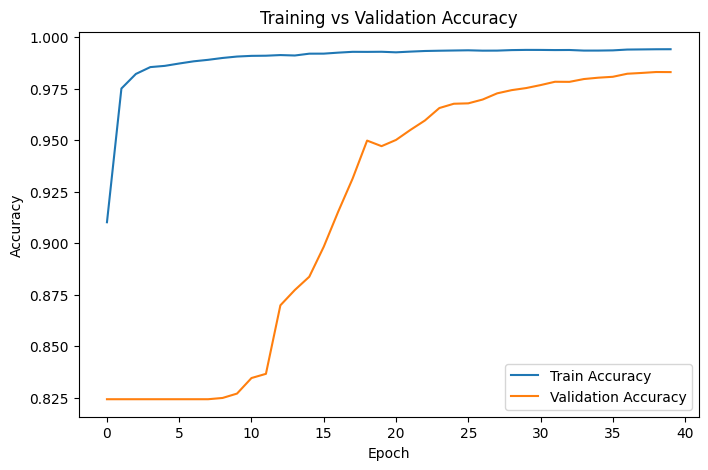

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

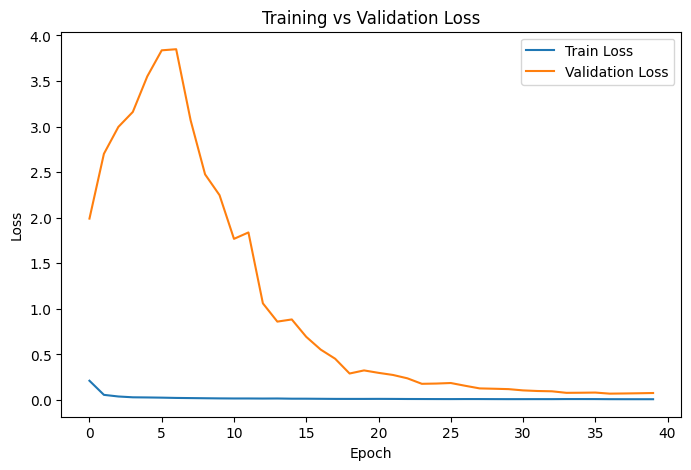

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [22]:
import tarfile, os

model.export("/kaggle/working/road_seg_savedmodel")

with tarfile.open("/kaggle/working/model.tar.gz", "w:gz") as tar:
    tar.add("/kaggle/working/road_seg_savedmodel", arcname=".")

INFO:tensorflow:Assets written to: /kaggle/working/road_seg_savedmodel/assets


INFO:tensorflow:Assets written to: /kaggle/working/road_seg_savedmodel/assets


Saved artifact at '/kaggle/working/road_seg_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None)
Captures:
  133834578810192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133834578812496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133834578811920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133834578813072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133834578810384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133834578810768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133834578814416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133834578815760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133834578817680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133834578817872: TensorSpec(shape=(), dtype=tf.resource

2026-03-14 17:37:21.739208: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:37:21.993641: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


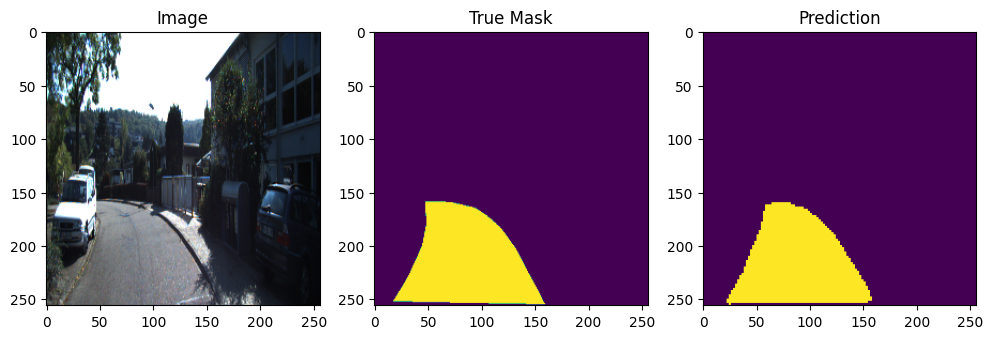

In [23]:
idx = 4
pred = model.predict(X_val[idx:idx+1])

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_val[idx])
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(Y_val[idx].squeeze())
plt.title("True Mask")

plt.subplot(1,3,3)
plt.imshow(pred[0].squeeze() > 0.5)
plt.title("Prediction")

plt.show()

In [28]:
video_path = "/kaggle/input/datasets/sakshaymahna/kittiroadsegmentation/testing/solidYellowLeft.mp4"

cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

print(width, height, fps)

960 540 25.0


In [29]:
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter("/kaggle/working/output.mp4",fourcc,fps,(width, height))

In [30]:
IMG_SIZE = 256

def process_frame(frame):

    original = frame.copy()

    small = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    small = small / 255.0

    pred = model.predict(small[np.newaxis,...])[0]

    mask = pred.squeeze() > 0.5

    mask = cv2.resize(mask.astype(np.uint8), (width, height))

    overlay = original.copy()
    overlay[mask == 1] = [0,255,0]

    return overlay

In [31]:
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    result = process_frame(frame)
    out.write(result)
cap.release()
out.release()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━